In [3]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath("../.."))
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from tinyconformal.regressor import ConformalizedRegressor
from sklearn.datasets import fetch_california_housing
import numpy as np

In [4]:
EXAMPLES_DIR = Path.cwd().parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
from utils.plot_utils import plot_prediction_intervals

In [5]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [7]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [8]:
reg = ConformalizedRegressor(rf, alpha=0.20)
reg.fit(X=X_calib, y=y_calib)

,learner,RandomForestR...ndom_state=42)
,alpha,0.2
,n_estimators,100
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [10]:
y_pred_intervals = reg.predict_interval(X_test)
y_pred = np.mean(y_pred_intervals, axis=1)

In [11]:
reg.evaluate(X_test, y_test)

{'total': 4128,
 'alpha': 0.2,
 'coverage_rate': np.float64(0.804),
 'interval_width_mean': np.float64(1.049),
 'mwis': np.float64(1.908)}

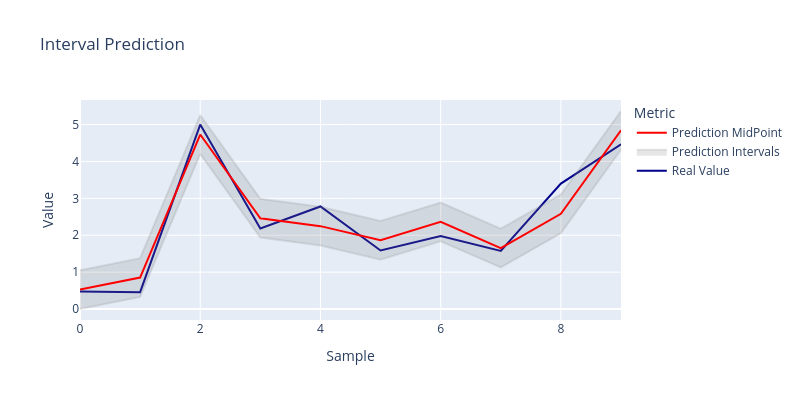

In [12]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")